In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv("../data/processed/traffic_hourly_clean.csv", parse_dates=["date_time"])


df["hour"] = df["date_time"].dt.hour
df["day_of_week"] = df["date_time"].dt.dayofweek
df["month"] = df["date_time"].dt.month                  
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)


df["lag_1"] = df["traffic_volume"].shift(1)
df["lag_2"] = df["traffic_volume"].shift(2)
df["lag_24"] = df["traffic_volume"].shift(24)
df["lag_168"] = df["traffic_volume"].shift(168)


df["roll_3"] = df["traffic_volume"].shift(1).rolling(3, min_periods=2).mean()
df["roll_24"] = df["traffic_volume"].shift(1).rolling(24, min_periods=12).mean()

df["roll_3_b"] = df["traffic_volume"].shift(24).rolling(3, min_periods=2).mean()
df["roll_24_b"] = df["traffic_volume"].shift(24).rolling(24, min_periods=12).mean()

df["temp_c"] = df["temp"] - 273.15


df["pred_naive"] = df["traffic_volume"].shift(168)


df_new = df.dropna(subset=["traffic_volume"]).copy()


train_end = "2016-09-30 23:00"
valid_end = "2017-09-30 23:00"
train = df_new[df_new["date_time"] <= train_end]
validate = df_new[(df_new["date_time"] > train_end) & (df_new["date_time"] <= valid_end)]
test = df_new[df_new["date_time"] > valid_end]


print(len(train), len(validate), len(test))   
print(df.columns.tolist())

23125 8683 8733
['date_time', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main', 'weather_description', 'traffic_volume', 'is_holiday', 'hour', 'day_of_week', 'month', 'is_weekend', 'lag_1', 'lag_2', 'lag_24', 'lag_168', 'roll_3', 'roll_24', 'roll_3_b', 'roll_24_b', 'temp_c', 'pred_naive']


In [2]:

features_a = [
    "hour", "day_of_week", "month", "is_weekend", "is_holiday",
    "lag_1", "lag_2", "lag_24", "lag_168", "roll_3", "roll_24",
    "temp_c", "rain_1h", "snow_1h", "clouds_all",
    ]
target = "traffic_volume"

            
assert target not in features_a

            
X_train, y_train = train[features_a], train[target]
X_valid, y_valid = validate[features_a], validate[target]

    
print(X_train.shape, X_valid.shape)    
print(X_train.dtypes)                  
print(X_train.isna().sum())            

(23125, 15) (8683, 15)
hour             int32
day_of_week      int32
month            int32
is_weekend       int64
is_holiday       int64
lag_1          float64
lag_2          float64
lag_24         float64
lag_168        float64
roll_3         float64
roll_24        float64
temp_c         float64
rain_1h        float64
snow_1h        float64
clouds_all     float64
dtype: object
hour              0
day_of_week       0
month             0
is_weekend        0
is_holiday        0
lag_1          2524
lag_2          1635
lag_24         2104
lag_168        2986
roll_3         1704
roll_24         560
temp_c            4
rain_1h           0
snow_1h           0
clouds_all        0
dtype: int64


In [3]:
print(X_train.isna().sum())
print(X_valid.isna().sum())

hour              0
day_of_week       0
month             0
is_weekend        0
is_holiday        0
lag_1          2524
lag_2          1635
lag_24         2104
lag_168        2986
roll_3         1704
roll_24         560
temp_c            4
rain_1h           0
snow_1h           0
clouds_all        0
dtype: int64
hour            0
day_of_week     0
month           0
is_weekend      0
is_holiday      0
lag_1          49
lag_2          53
lag_24         72
lag_168        77
roll_3         20
roll_24         0
temp_c          0
rain_1h         0
snow_1h         0
clouds_all      0
dtype: int64


In [4]:
print(df.loc[train.index, "roll_24"].isna().sum())   
print(train["roll_24"].isna().sum())                  

560
560


In [5]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error


model = XGBRegressor(
    n_estimators=300,      #  number of trees
    learning_rate=0.05,    # step size
    max_depth=6,           # tree depth
    random_state=42,       # reproducible results
    )

                # ---------- 2) ا Train on train ONLY ----------
model.fit(X_train, y_train)

                # ---------- 3) Predict on validation ----------
pred = model.predict(X_valid)

                # ---------- 4)  MAE on all rows ----------
mae_all = mean_absolute_error(y_valid, pred)

                
                # ---------- 5) MAE on the SAME rows as the baselines (fair comparison) ----------
same = X_valid["lag_168"].notna().values
mae_same = mean_absolute_error(y_valid[same], pred[same])
mean_traffic = y_valid[same].mean()

print("rows:", len(y_valid), "| same-rows:", same.sum())
print(f"XGBoost MAE (all rows):  {mae_all:.0f}")
print(f"XGBoost MAE (same rows): {mae_same:.0f}  ({mae_same / mean_traffic:.1%} of mean)")
print("Baselines on same rows -> Naive-168: 302 | Hour-of-week avg: 277")

rows: 8683 | same-rows: 8606
XGBoost MAE (all rows):  161
XGBoost MAE (same rows): 161  (4.8% of mean)
Baselines on same rows -> Naive-168: 302 | Hour-of-week avg: 277


In [6]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

# ---------- 1)  Option B feature list ----------
features_b = [
    "hour", "day_of_week", "month", "is_weekend", "is_holiday",
    "lag_24", "lag_168", "roll_3_b", "roll_24_b",
    "temp_c", "rain_1h", "snow_1h", "clouds_all",
]

# Safety: no feature may use the last 23 hours before the target
forbidden = ["lag_1", "lag_2", "roll_3", "roll_24", "traffic_volume"]
assert not any(c in features_b for c in forbidden)

X_train_b, y_train_b = train[features_b], train["traffic_volume"]
X_valid_b, y_valid_b = validate[features_b], validate["traffic_volume"]

# ---------- 2) Train model B, same settings ----------
model_b = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
)
model_b.fit(X_train_b, y_train_b)
pred_b = model_b.predict(X_valid_b)

# ---------- 3) Model A for comparison ----------
pred_a = model.predict(X_valid)

# ---------- 4)  Same rows for every model ----------
same = X_valid_b["lag_168"].notna().values
y_same = y_valid_b[same]
mean_traffic = y_same.mean()

mae_a = mean_absolute_error(y_same, pred_a[same])
mae_b = mean_absolute_error(y_same, pred_b[same])

print("rows compared:", same.sum())
print(f"Naive-168 (baseline): 302")
print(f"Hour-of-week avg (baseline): 277")
print(f"XGBoost A (1h ahead): {mae_a:.0f} ({mae_a / mean_traffic:.1%} of mean)")
print(f"XGBoost B (24h ahead): {mae_b:.0f} ({mae_b / mean_traffic:.1%} of mean)")

rows compared: 8606
Naive-168 (baseline): 302
Hour-of-week avg (baseline): 277
XGBoost A (1h ahead): 161 (4.8% of mean)
XGBoost B (24h ahead): 222 (6.7% of mean)


lag_168        0.659343
hour           0.141125
is_holiday     0.061288
lag_24         0.042075
day_of_week    0.038362
roll_3_b       0.027730
month          0.006821
roll_24_b      0.006169
snow_1h        0.004954
rain_1h        0.004681
temp_c         0.004507
clouds_all     0.002945
is_weekend     0.000000
dtype: float32


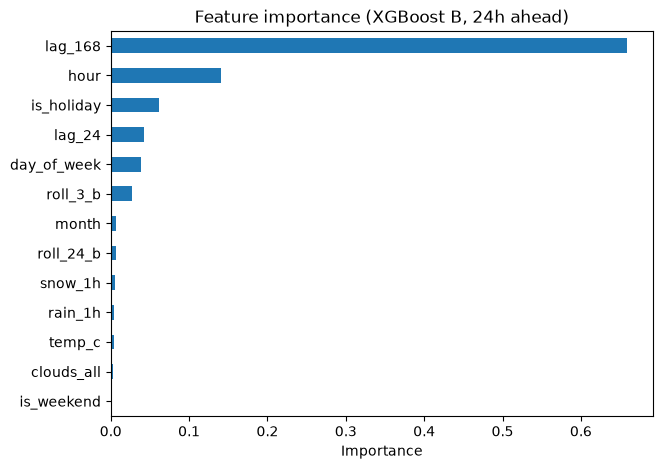

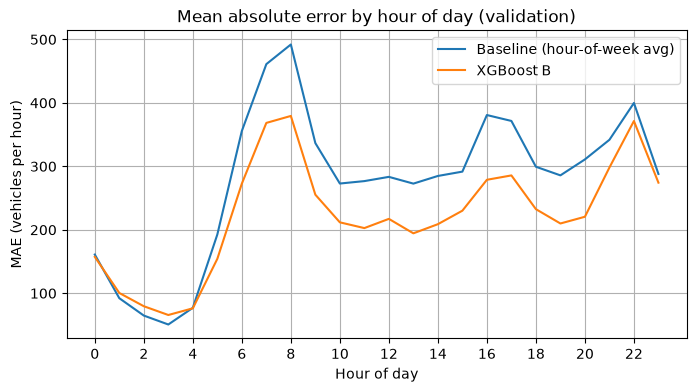

                 err_b     err_avg
is_holiday                        
0           214.464498  257.961941
1           488.112224  882.302896
is_holiday
0    8422
1     261
dtype: int64


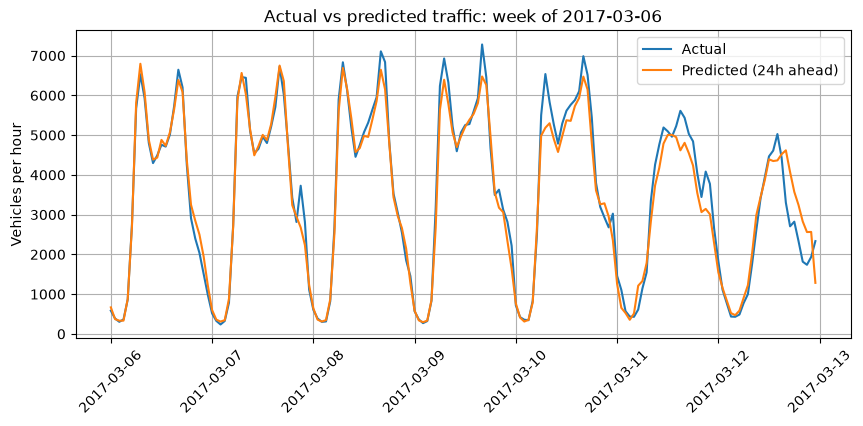

In [7]:


import matplotlib.pyplot as plt

# ---------- 0)  Build the analysis table ----------
# Baseline (hour-of-week mean) from TRAIN only, for comparison
avg_table = (
    train.groupby(["day_of_week", "hour"])["traffic_volume"]
    .mean().reset_index().rename(columns={"traffic_volume": "pred_avg"})
)
val = validate.merge(avg_table, on=["day_of_week", "hour"], how="left")
val["pred_b"] = pred_b #   model B predictions
val["err_b"] = (val["traffic_volume"] - val["pred_b"]).abs()
val["err_avg"] = (val["traffic_volume"] - val["pred_avg"]).abs()

# ---------- 1) Feature importance ----------
imp = pd.Series(model_b.feature_importances_, index=features_b).sort_values()
print(imp.sort_values(ascending=False))

plt.figure(figsize=(7, 5))
imp.plot(kind="barh")
plt.title("Feature importance (XGBoost B, 24h ahead)")
plt.xlabel("Importance")
plt.savefig("../reports/figures/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

# ---------- 2) Error by hour of day ----------
err_by_hour = val.groupby("hour")[["err_b", "err_avg"]].mean()

plt.figure(figsize=(8, 4))
plt.plot(err_by_hour.index, err_by_hour["err_avg"], label="Baseline (hour-of-week avg)")
plt.plot(err_by_hour.index, err_by_hour["err_b"], label="XGBoost B")
plt.title("Mean absolute error by hour of day (validation)")
plt.xlabel("Hour of day")
plt.ylabel("MAE (vehicles per hour)")
plt.xticks(range(0, 24, 2))
plt.legend()
plt.grid(True)
plt.savefig("../reports/figures/error_by_hour.png", dpi=150, bbox_inches="tight")
plt.show()

# ---------- 3)  Error on public holidays ----------
print(val.groupby("is_holiday")[["err_b", "err_avg"]].mean())
print(val.groupby("is_holiday").size()) # كم ساعة لكل مجموعة | hours per group

# ---------- 4) Actual vs predicted for one week ----------
week = val[(val["date_time"] >= "2017-03-06") & (val["date_time"] < "2017-03-13")]

plt.figure(figsize=(10, 4))
plt.plot(week["date_time"], week["traffic_volume"], label="Actual")
plt.plot(week["date_time"], week["pred_b"], label="Predicted (24h ahead)")
plt.title("Actual vs predicted traffic: week of 2017-03-06")
plt.ylabel("Vehicles per hour")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.savefig("../reports/figures/actual_vs_pred_week.png", dpi=150, bbox_inches="tight")
plt.show()
